In [7]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] = 0

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df['target'] = 1

df = pd.concat([df, df1], ignore_index = True)   #df.append = remove

df = df.sample(40)

In [8]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1.0
34,0.177061,-0.598109,1.226512,NaN
14,0.420623,0.411620,-0.071324,1.0
11,1.968435,-0.547788,-0.679418,1.0
12,-2.506230,0.146960,0.606195,1.0


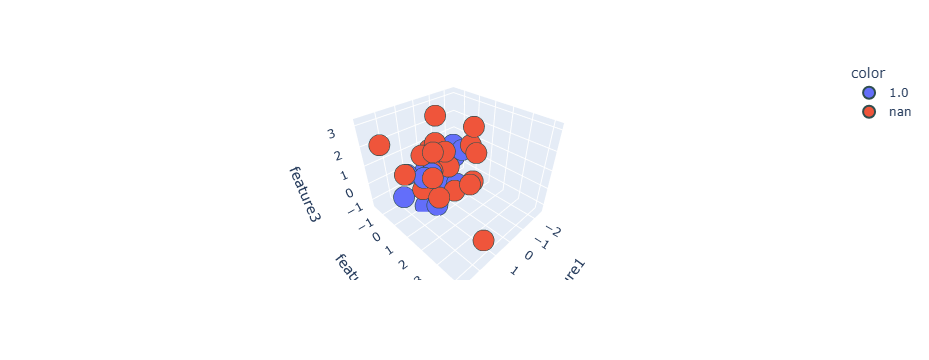

In [10]:
import plotly.express as px

# y_train_trf = y_train.astype(str)

fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
                   color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                             line=dict(width=2, color='DarkSlateGrey')),
                 selector=dict(mode='markers'))
fig.show()

In [12]:
# step 1 - Applying standerd scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [14]:
# find covvariance matrix
covariance_matrix = np.cov([df.iloc[:,0], df.iloc[:,1], df.iloc[:,2]])
print('Covariante Matrix :\n',covariance_matrix)

Covariante Matrix :
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [27]:
# step 3 --> finding Evalue and Evectors

eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [28]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [29]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

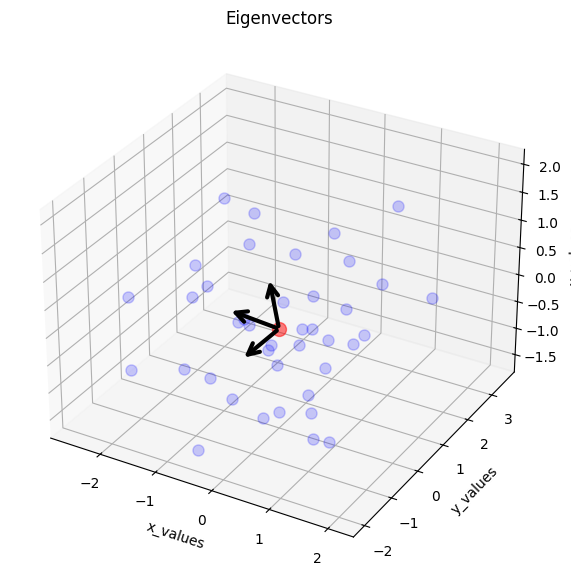

In [46]:
%matplotlib inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch) : 
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None) :
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return min(zs)
      
    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'],df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)

for v in eigen_vectors:
    a = Arrow3D([df['feature1'].mean(), v[0]],
                [df['feature2'].mean(), v[1]],
                [df['feature3'].mean(), v[2]],
                mutation_scale=20, lw=3,
               arrowstyle= '->')
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('x_values')

plt.title('Eigenvectors')

plt.show()        

In [47]:
pc = eigen_vactors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [49]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)

# 40,3 -- 3,2
new_df = pd.DataFrame(transformed_df, columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1.0
1,1.056919,-0.212737,NaN
2,-0.271876,0.498222,1.0
3,-0.621586,0.023110,1.0
4,1.567286,1.730967,1.0


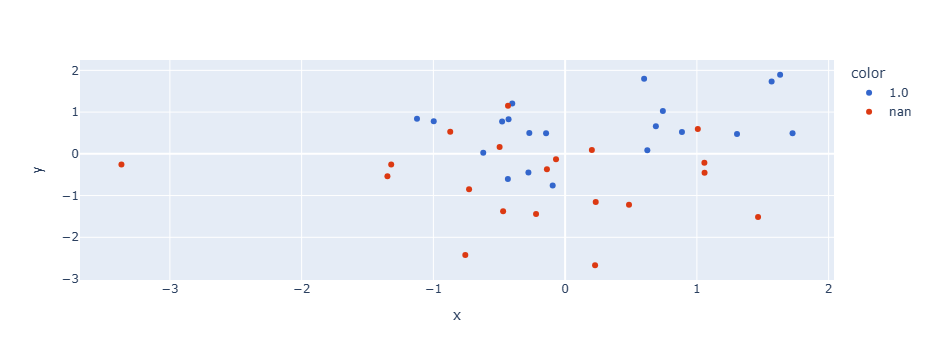

In [53]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=12,
                             line=dict(width=2,
                                      color='DarkSlateGrey')),
                 selector=dict(mode='marker'))
fig.show()